In [1]:
# Import necessary packages
import torch
from torch import nn
import torchinfo
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
import time


import brevitas.nn as qnn
from brevitas.quant import Int8Bias
from brevitas.inject.enum import ScalingImplType
from brevitas.inject.defaults import Int8ActPerTensorFloatMinMaxInit

# Prepare data loader
from torch.utils.data import Dataset, DataLoader
import h5py
from sklearn.metrics import accuracy_score

In [2]:
# Make sure that CUDA is available - without cuda we would be attempting to run the model on CPU which is tooooo slow. 
assert torch.cuda.is_available(), 'Cuda not available'

In [3]:
class radio_dataset(Dataset):
    all_IQ=[]
    all_mod=[]
    all_snr=[]
    train_sampler:torch.utils.data.SubsetRandomSampler
    val_sampler:torch.utils.data.SubsetRandomSampler
    test_sampler:torch.utils.data.SubsetRandomSampler
    def __init__(self,dataset_path:str,fpmsc:int=4096):
        iq_key="all_IQ_8bit"
        mod_key="all_labels"
        snr_key="all_SNRs"
        
        np.random.seed(2021) #maintain deterministic randomness
        print(f"loading {dataset_path}")
        h5_file = h5py.File(dataset_path,'r')
        # print(f"All available keys: {list(h5_file.keys())}")
        self.all_IQ = h5_file[iq_key]
        self.all_mod = h5_file[mod_key][:,0].flatten()
        self.all_snr = h5_file[snr_key][:,0].flatten()
        # print(f"Raw values shape: {self.all_IQ.shape}")
        # print(f"Raw values min/max range: {np.min(self.all_IQ)}, {np.max(self.all_IQ)}, {self.all_IQ.dtype}")
        # print(f"Labels shape: {self.all_mod.shape}")
        # print(f"SNR shape: {self.all_snr.shape}")
        
        train_indices = []
        test_indices = []
        val_indices = []
        # fpmsc: frames per mod snr combination, the dataset is organized as mod major, snr minor
        # each mod-snr-combination has fpsmc frames, we split those fpsmc frames uniformly to train, test, val indices
        for i in range(0,len(self.all_IQ),fpmsc):
            indices_subclass=list(range(i,i+fpmsc))
            split = int(np.ceil(0.8 * fpmsc)) #split 80,10,10
            split2 = int(np.ceil(0.9 * fpmsc))
            
            np.random.shuffle(indices_subclass)
            
            train_indices_subclass = indices_subclass[:split]
            val_indices_subclass = indices_subclass[split:split2]
            test_indices_subclass = indices_subclass[split2:]
            
            train_indices.extend(train_indices_subclass)
            test_indices.extend(test_indices_subclass)
            val_indices.extend(val_indices_subclass) 
        
        self.train_sampler = torch.utils.data.SubsetRandomSampler(train_indices)
        self.val_sampler = torch.utils.data.SubsetRandomSampler(val_indices)
        self.test_sampler = torch.utils.data.SubsetRandomSampler(test_indices)
        
        # print('Training set size: ',len(self.train_sampler))
        # print('Val set size: ',len(self.val_sampler))
        # print('Test set size: ',len(self.test_sampler))
    
    def __getitem__(self, idx):
        # transpose frame into Pytorch channels-first format (NCL = -1,2,1024)
        return self.all_IQ[idx].transpose(), self.all_mod[idx], self.all_snr[idx]

In [4]:
def quantized_vgg10(model_body_bit:int)->nn.Sequential:
    a_bits = model_body_bit  # a_bits is the bit width for ReLu
    w_bits = model_body_bit # w_bits is the bit width for all the weights
    
    input_bits:int=8
    new_min=-128.0
    new_max=128
    filters_conv = 64
    filters_dense = 128
    
    class InputQuantizer(Int8ActPerTensorFloatMinMaxInit):
        #Quantize to input_bits
        bit_width = input_bits
        
        #Min max value of the input. Set to the range value of the input 
        min_val = new_min #the min value of the input(dataset) before going through the model
        max_val = new_max #the max value of the input(dataset) before going through the model
        scaling_impl_type = ScalingImplType.CONST # Fix the quantization range to [min_val, max_val]
    
    return nn.Sequential(
            # Input quantization layer
            qnn.QuantHardTanh(act_quant=InputQuantizer),
        
            qnn.QuantConv1d(2, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_conv),
            qnn.QuantReLU(bit_width=a_bits),
            nn.MaxPool1d(2),
        
            qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_conv),
            qnn.QuantReLU(bit_width=a_bits),
            nn.MaxPool1d(2),
        
            qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_conv),
            qnn.QuantReLU(bit_width=a_bits),
            nn.MaxPool1d(2),
        
            qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits,bias=False),
            nn.BatchNorm1d(filters_conv),
            qnn.QuantReLU(bit_width=a_bits),
            nn.MaxPool1d(2),
        
            qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_conv),
            qnn.QuantReLU(bit_width=a_bits),
            nn.MaxPool1d(2),
        
            qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_conv),
            qnn.QuantReLU(bit_width=a_bits),
            nn.MaxPool1d(2),
        
            qnn.QuantConv1d(filters_conv, filters_conv, 3, padding=1, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_conv),
            qnn.QuantReLU(bit_width=a_bits),
            nn.MaxPool1d(2),
            
            nn.Flatten(),
        
            qnn.QuantLinear(filters_conv*8, filters_dense, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_dense),
            qnn.QuantReLU(bit_width=a_bits),
        
            qnn.QuantLinear(filters_dense, filters_dense, weight_bit_width=w_bits, bias=False),
            nn.BatchNorm1d(filters_dense),
            qnn.QuantReLU(bit_width=a_bits, return_quant_tensor=True),
        
            qnn.QuantLinear(filters_dense, 15, weight_bit_width=w_bits, bias=True, bias_quant=Int8Bias),
        )

def vanilla_vgg10()->nn.Sequential:
    filters_conv = 64
    filters_dense = 128
    class VGG10(nn.Module):
        def __init__(self):
            super().__init__()
            
            # Conv block 1
            self.conv1 = nn.Conv1d(2, filters_conv, 3, padding=1)
            self.bn1 = nn.BatchNorm1d(filters_conv)
            self.relu1 = nn.ReLU()
            self.pool1 = nn.MaxPool1d(2)
            
            # Conv block 2
            self.conv2 = nn.Conv1d(filters_conv, filters_conv, 3, padding=1)
            self.bn2 = nn.BatchNorm1d(filters_conv)
            self.relu2 = nn.ReLU()
            self.pool2 = nn.MaxPool1d(2)
            
            # Conv block 3
            self.conv3 = nn.Conv1d(filters_conv, filters_conv, 3, padding=1)
            self.bn3 = nn.BatchNorm1d(filters_conv)
            self.relu3 = nn.ReLU()
            self.pool3 = nn.MaxPool1d(2)
            
            # Conv block 4
            self.conv4 = nn.Conv1d(filters_conv, filters_conv, 3, padding=1)
            self.bn4 = nn.BatchNorm1d(filters_conv)
            self.relu4 = nn.ReLU()
            self.pool4 = nn.MaxPool1d(2)
            
            # Conv block 5
            self.conv5 = nn.Conv1d(filters_conv, filters_conv, 3, padding=1)
            self.bn5 = nn.BatchNorm1d(filters_conv)
            self.relu5 = nn.ReLU()
            self.pool5 = nn.MaxPool1d(2)
            
            # Conv block 6
            self.conv6 = nn.Conv1d(filters_conv, filters_conv, 3, padding=1)
            self.bn6 = nn.BatchNorm1d(filters_conv)
            self.relu6 = nn.ReLU()
            self.pool6 = nn.MaxPool1d(2)
            
            # Conv block 7
            self.conv7 = nn.Conv1d(filters_conv, filters_conv, 3, padding=1)
            self.bn7 = nn.BatchNorm1d(filters_conv)
            self.relu7 = nn.ReLU()
            self.pool7 = nn.MaxPool1d(2)
            
            self.flatten = nn.Flatten()
            
            # Dense block 1
            self.fc1 = nn.Linear(filters_conv*8, filters_dense)
            self.bn8 = nn.BatchNorm1d(filters_dense)
            self.relu8 = nn.ReLU()
            
            # Dense block 2
            self.fc2 = nn.Linear(filters_dense, filters_dense)
            self.bn9 = nn.BatchNorm1d(filters_dense)
            self.relu9 = nn.ReLU()
            
            # Output layer
            self.fc3 = nn.Linear(filters_dense, 15, bias=True)
    
        def forward(self, x):
            # Conv blocks
            x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
            x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
            x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
            x = self.pool4(self.relu4(self.bn4(self.conv4(x))))
            x = self.pool5(self.relu5(self.bn5(self.conv5(x))))
            x = self.pool6(self.relu6(self.bn6(self.conv6(x))))
            x = self.pool7(self.relu7(self.bn7(self.conv7(x))))
            
            x = self.flatten(x)
            
            # Dense blocks
            x = self.relu8(self.bn8(self.fc1(x)))
            x = self.relu9(self.bn9(self.fc2(x)))
            x = self.fc3(x)
            
            return x
    return VGG10()
# print(torchinfo.summary(model,input_size=(1,2,1024),depth=1));

In [5]:
class testing_result():
    y_pred=[]
    y_exp=[]
    y_snr=[]
    def __init__(self,pred,exp,snr):
        self.y_pred=pred
        self.y_exp=exp
        self.y_snr=snr

def get_dataset_path(r:str,ppm:int):
    match (r,ppm):
        case ("rician",0):
            return "datasets/MatGenData_ppm0_rician_int8_20260213.h5"
        case ("rician",20):
            return "datasets/MatGenData_ppm20_rician_int8_20250828.h5"
        case ("rayleigh",0):
            return "datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5"
        case ("rayleigh",20):
            return "datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5"
        case _:
            assert False,"invalid params"
            return

def get_model_path(r:str,ppm:int,bit:int):
    match (r,ppm,bit):
        case ("rician",0,32):
            return "archive/rician_matgen_ppm0_2026_feb13_report/vanilla/model_vanilla.pth"
        case ("rician",0,8):
            return "archive/rician_matgen_ppm0_2026_feb13_report/8bit/model_brevitas.pth"
        case ("rician",0,4):
            return "archive/rician_matgen_ppm0_2026_feb13_report/4bit/model_brevitas.pth"
        case ("rician",0,2):
            return "archive/rician_matgen_ppm0_2026_feb13_report/2bit/model_brevitas.pth"

        case ("rician",20,32):
            return "archive/rician_matgen_ppm20_2026_jan22_report/mat_gen_vanilla_10112025/model_vanilla.pth"
        case ("rician",20,8):
            return "archive/rician_matgen_ppm20_2026_jan22_report/mat_gen_8bit_10112025/model_brevitas.pth"
        case ("rician",20,4):
            return "archive/rician_matgen_ppm20_2026_jan22_report/mat_gen_4bit_01222026/model_brevitas.pth"
        case ("rician",20,2):
            return "archive/rician_matgen_ppm20_2026_jan22_report/mat_gen_2bit_01222026/model_brevitas.pth"

        case ("rayleigh",0,32):
            return "archive/rayleigh_matgen_0ppm_2026_jan28_report/vanilla/model_vanilla.pth"
        case ("rayleigh",0,8):
            return "archive/rayleigh_matgen_0ppm_2026_jan28_report/8bit/model_brevitas.pth"
        case ("rayleigh",0,4):
            return "archive/rayleigh_matgen_0ppm_2026_jan28_report/4bit/model_brevitas.pth"
        case ("rayleigh",0,2):
            return "archive/rayleigh_matgen_0ppm_2026_jan28_report/2bit/model_brevitas.pth"
            
        case ("rayleigh",20,32):
            return "archive/rayleigh_matgen_20ppm_2026_feb28_report/vanilla/model_vanilla.pth"
        case ("rayleigh",20,8):
            return "archive/rayleigh_matgen_20ppm_2026_feb28_report/8bit/model_brevitas.pth"
        case ("rayleigh",20,4):
            return "archive/rayleigh_matgen_20ppm_2026_feb28_report/4bit/model_brevitas.pth"
        case ("rayleigh",20,2):
            return "archive/rayleigh_matgen_20ppm_2026_feb28_report/2bit/model_brevitas.pth"

        case _:
            assert False,"invalid params"
            return

def get_model(r:str,ppm:int,bit:int):
    load_path=get_model_path(r,ppm,bit)
    model=nn.Sequential()
    if bit==32:
        model=vanilla_vgg10()
    else:
        model=quantized_vgg10(bit)
    
    model.load_state_dict(torch.load(load_path))
    model.to('cuda')
    return model

def get_model_testing_result(model, dataset_path:str, batch_size:int=1024)->testing_result:   
    model.to('cuda')
    # print(torchinfo.summary(model,input_size=(1,2,1024),depth=1));
    
    dataset=radio_dataset(dataset_path, 4096)
    test_dataset=DataLoader(dataset, batch_size=batch_size, sampler=dataset.test_sampler)
    y_pred = np.empty((0)) 
    y_exp = np.empty((0))
    y_snr = np.empty((0))
    model.eval()

    with torch.no_grad():
        for data in tqdm(test_dataset, desc="Batches"):
            inputs, target, snr = data
            inputs = inputs.to('cuda').float()
            output = model(inputs).cpu()
            #model raw output 15 mods prediction values, we can do the softmax here
            output = np.argmax(output,axis=1)
            y_pred = np.concatenate((y_pred,output))
            y_exp = np.concatenate((y_exp,target))
            y_snr = np.concatenate((y_snr,snr))

    return testing_result(y_pred,y_exp,y_snr)

In [6]:
def plot_confusion_matrix(cm,labels=[], name="", cmap=plt.cm.Blues, use_save=False, threshold=0.01):
    print(name)
    plt.figure(figsize=(12,8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    # plt.title(name)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=90)
    plt.yticks(tick_marks, labels)
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i,j]>threshold or i==j: #condition to show on plot
                plt.text(j, i, f"{cm[i, j]:.2f}", 
                         ha="center", va="center",
                         color="white" if cm[i, j] > cm.max()/2 else "black")
                
    # plt.plot(np.arange(cm.shape[0]), np.arange(cm.shape[1]), 
    #          color='red', linestyle='--', linewidth=1.5, alpha=0.25)

    plt.grid(visible=True, color='gray', linestyle='--', linewidth=0.5, alpha=0.25)
    if use_save:
        plt.savefig(f'{name}.jpeg', bbox_inches='tight',format='jpeg')
    # plt.show()
    plt.close();
    

def get_cm(test_result:testing_result, label_count:int, normalized:bool=True, filter_snr=None):
    
    conf = np.zeros([label_count,label_count])
    confnorm = np.zeros([label_count,label_count])

    ye=test_result.y_exp
    yp=test_result.y_pred
    ysnr=test_result.y_snr
    #raw confusion mat
    for i in range(len(ye)):
        if (filter_snr is not None) and (ysnr[i] not in filter_snr):
            continue
        e = int(ye[i]) #index label of expected -> major axis / y axis
        p = int((yp[i])) #index label of prediction -> minor axis / x axis
        conf[e,p] = conf[e,p] + 1

    if (not normalized):
        return conf
    
    #norm confusion mat
    for i in range(label_count): #go from top down, divide all cells in each row by the sum of each row to normalize. all cells each row should sum up to 1
        row_sum=np.sum(conf[i,:])
        if row_sum>0.0:
            confnorm[i,:] = conf[i,:] / row_sum
        else:
            confnorm[i,:] = 0.0
            
    return confnorm

In [7]:
def get_acc_breakdown_over_snr(test_result:testing_result, label_count:int):
    snr_list=np.unique(test_result.y_snr)
    
    correct=np.zeros([len(snr_list),label_count])
    total=np.zeros([len(snr_list),label_count])
    index:int=0
    for s in snr_list:
        conf=get_cm(test_result, label_count, normalized=False, filter_snr=[s])
        for m in range(label_count):
            correct[index,m]=conf[m,m]
            total[index,m]=np.sum(np.sum(conf[m,:]))
        index+=1
    return correct,total

def graph_multiline(data, x_data, x_label, legends=None, name="", xlabel="SNR(dB)", ylabel="Acc.", use_save=False):
    print(name)
    fntsize=16
    markers = ['o', 's', '^', 'd', 'v', 'p', '*']
    plt.figure(figsize=(12,8))
    # plt.plot(x_data,data)
    for i, y in enumerate(np.array(data).T):
        plt.plot(x_data, y, marker=markers[i % len(markers)], markersize=10)
    
    plt.grid(True)
    if legends is not None:
        plt.legend(legends, loc='lower right', bbox_to_anchor=(1.0,0.0),fontsize=fntsize)
    # plt.title(name,fontsize=fntsize)
    plt.xticks(x_label,fontsize=fntsize)
    # plt.setxticks(np.arange(0,31.0,5.0))
    # plt.axes.set_xticks(np.arange(0,31.0,5.0))
    plt.yticks(np.arange(0, 1.1, 0.1),fontsize=fntsize)
    plt.tight_layout()
    plt.xlabel(xlabel,fontsize=fntsize*1.25)
    plt.ylabel(ylabel,fontsize=fntsize*1.25)
    if use_save:
        plt.savefig(f'{name}.jpeg', bbox_inches='tight',format='jpeg')
    plt.show()

## Main

loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/torch/_tensor.py:1255: UserWarning: Named tensors and all their associated APIs are an experimental feature and subject to change. Please do not use them for anything important until they are released as stable. (Triggered internally at ../c10/core/TensorImpl.h:1758.)
  return super(Tensor, self).rename(names)


loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rician_PPM0]-test[rician_PPM0]


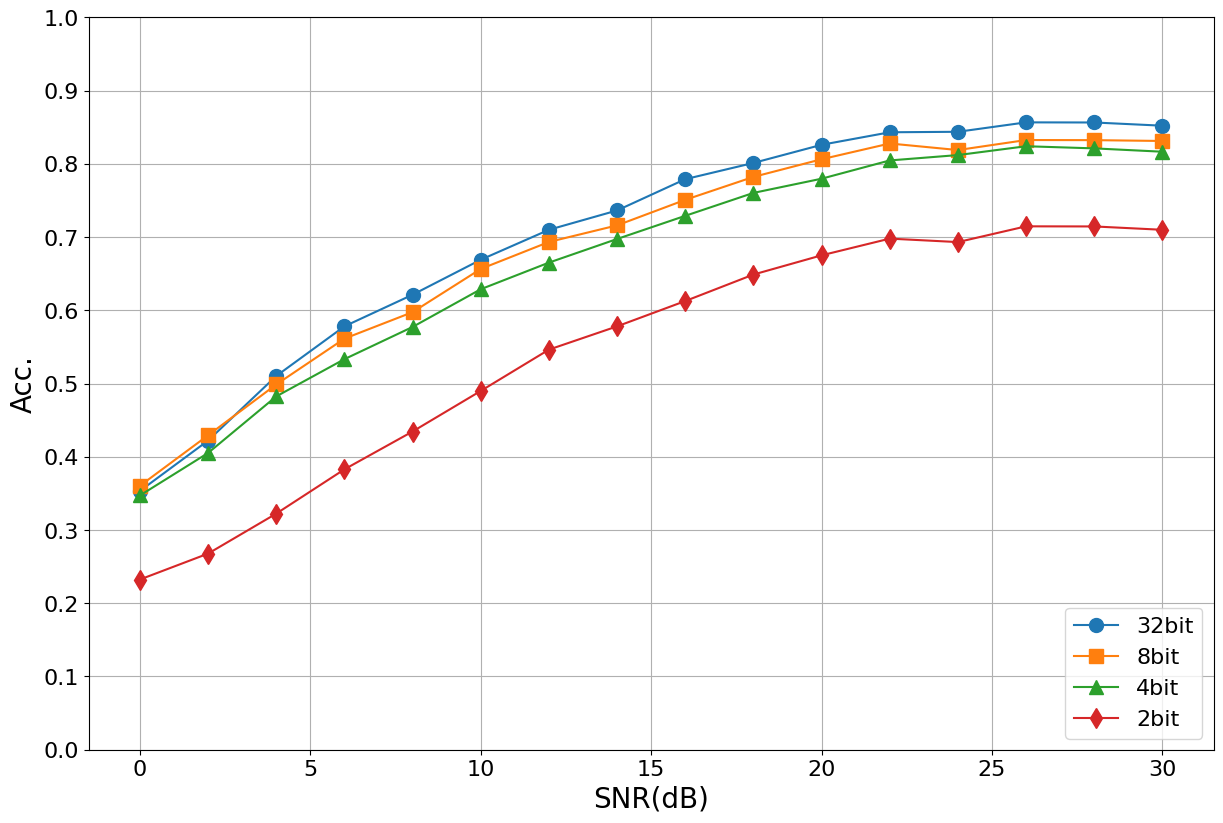

loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rician_PPM20]-test[rician_PPM0]


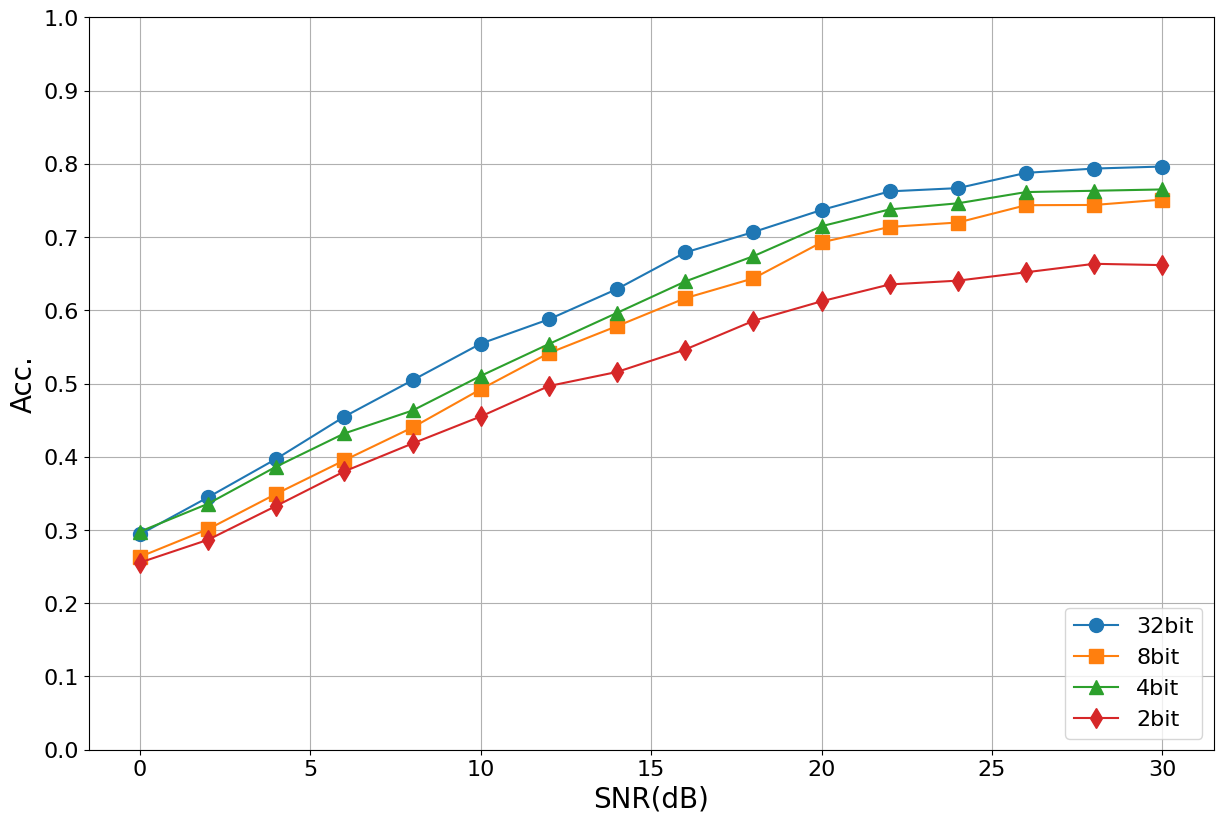

loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rayleigh_PPM0]-test[rician_PPM0]


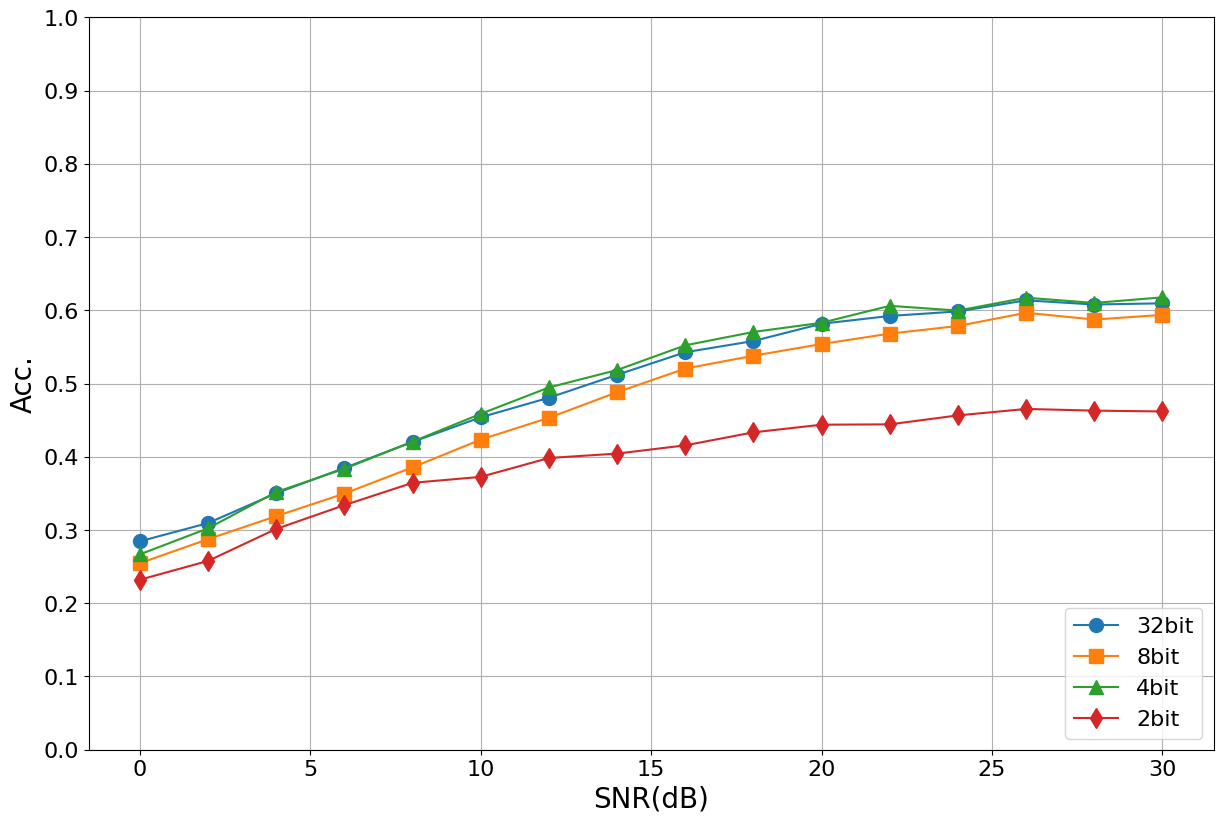

loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rician_int8_20260213.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rayleigh_PPM20]-test[rician_PPM0]


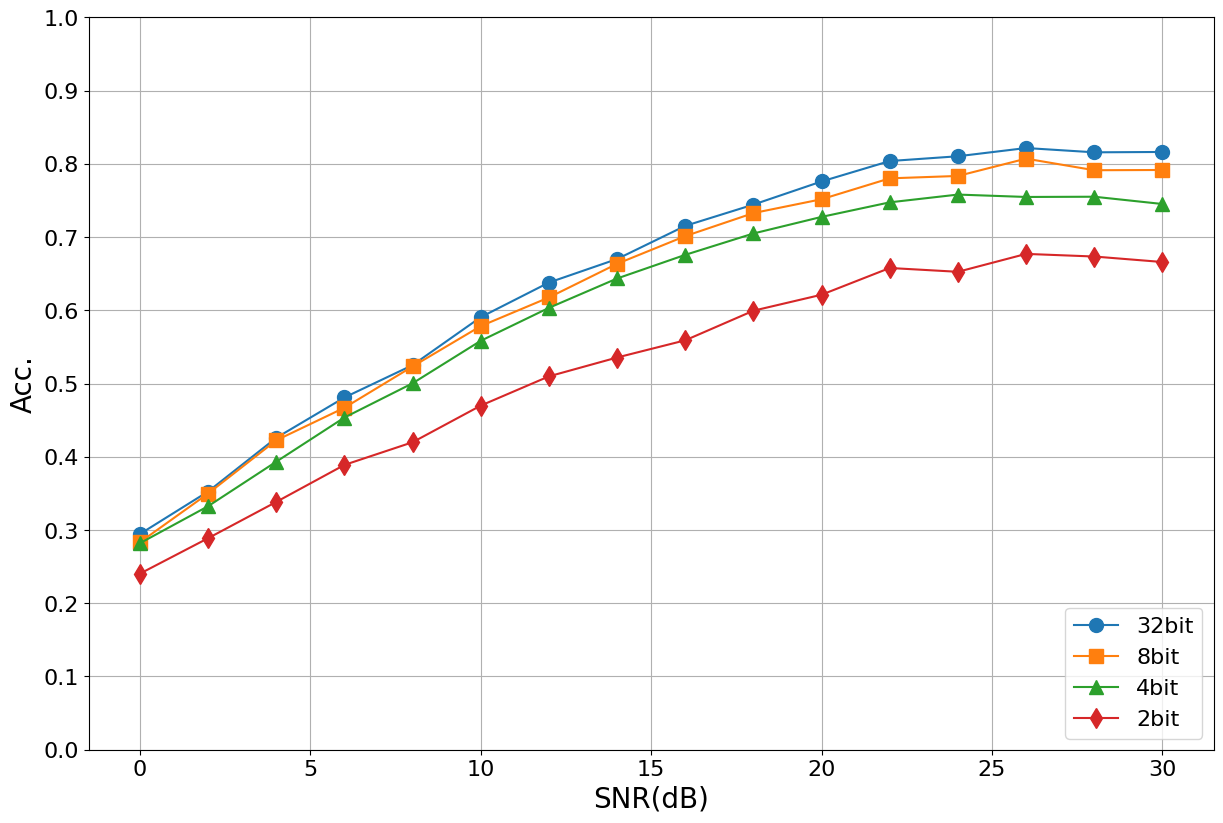

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rician_PPM0]-test[rician_PPM20]


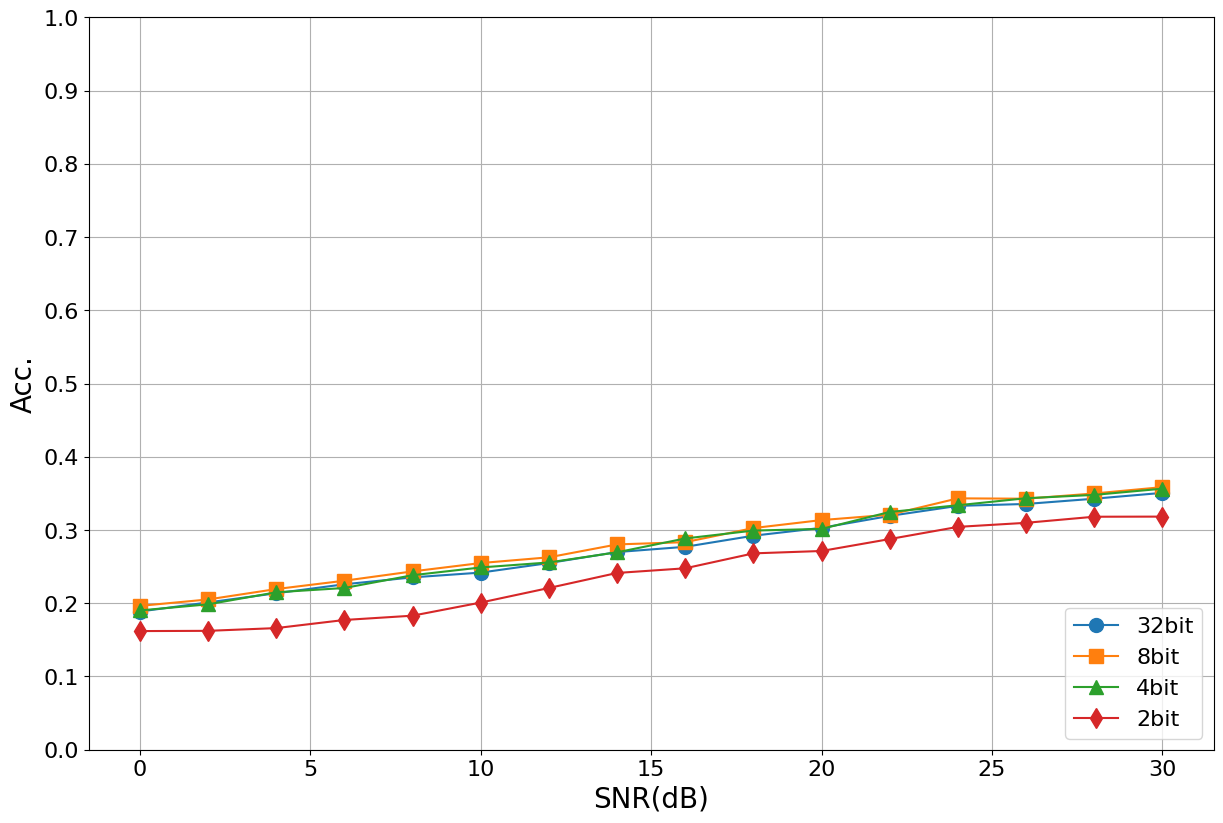

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rician_PPM20]-test[rician_PPM20]


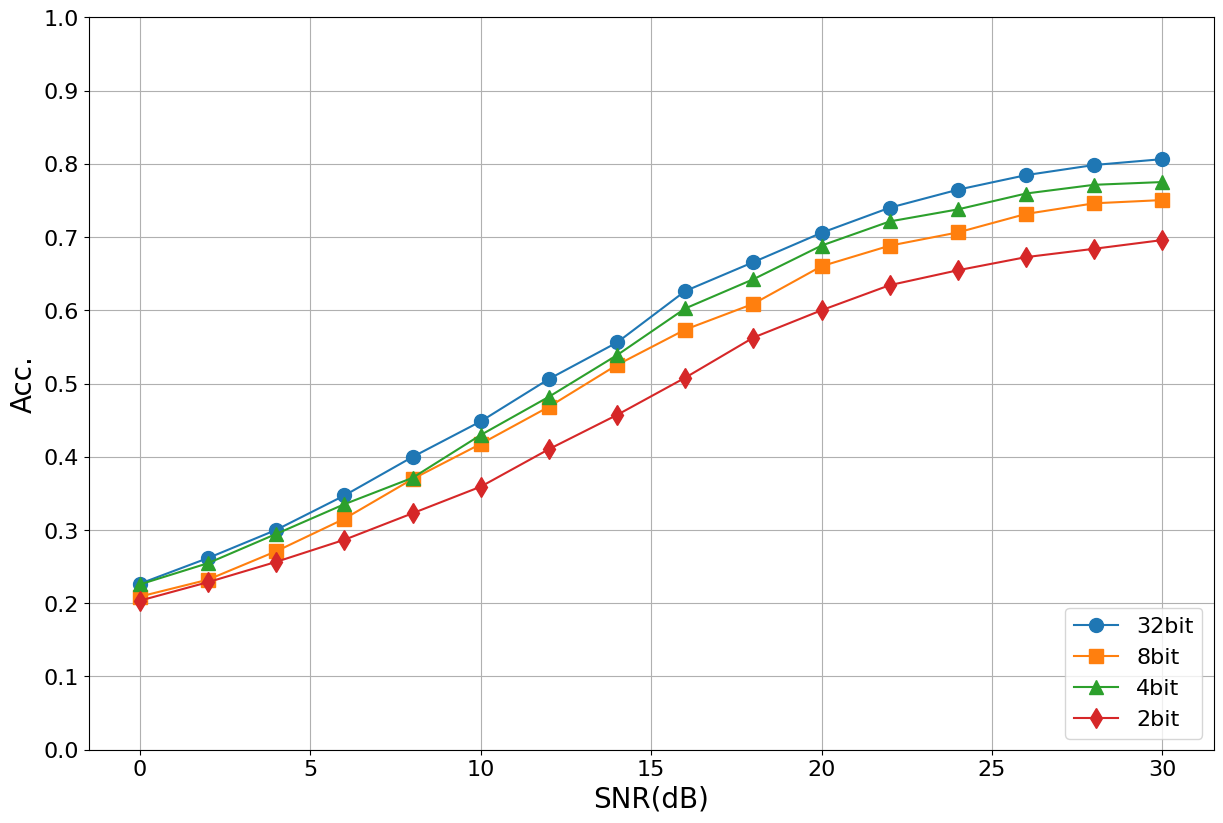

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rayleigh_PPM0]-test[rician_PPM20]


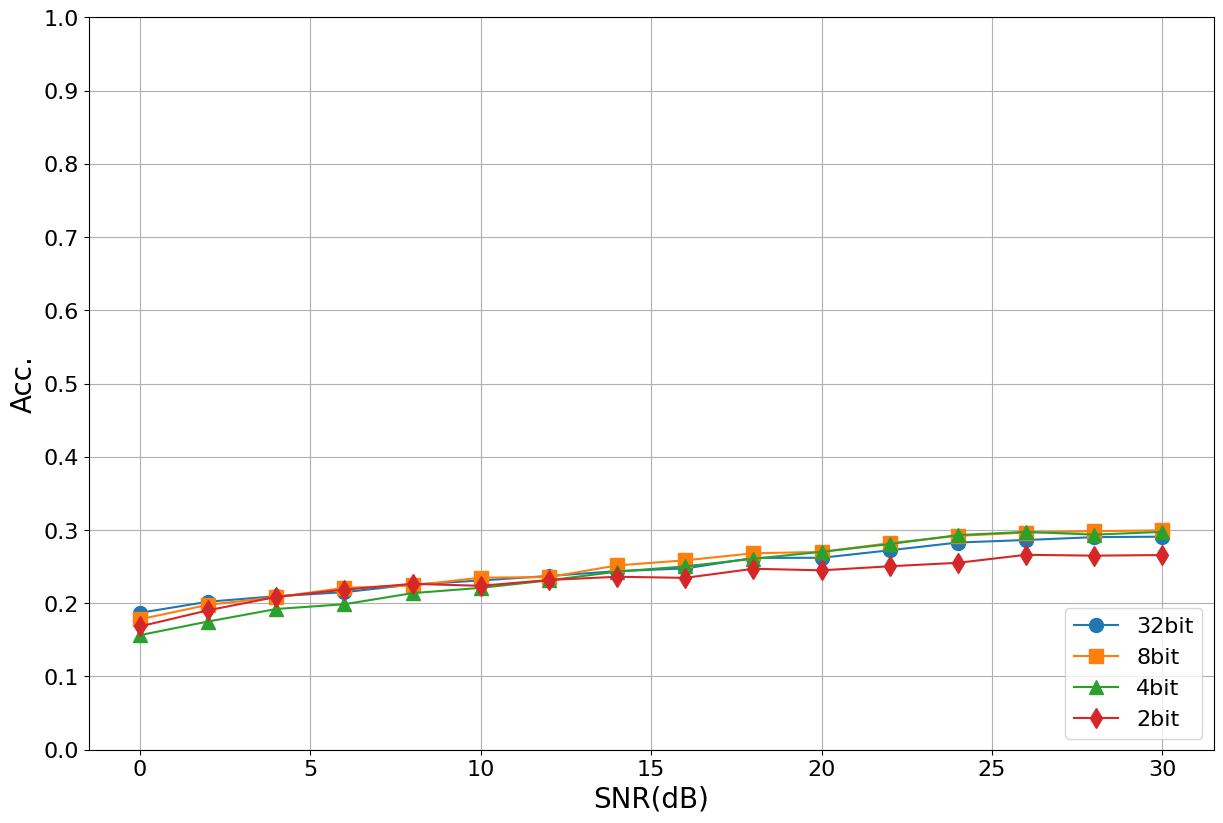

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rician_int8_20250828.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rayleigh_PPM20]-test[rician_PPM20]


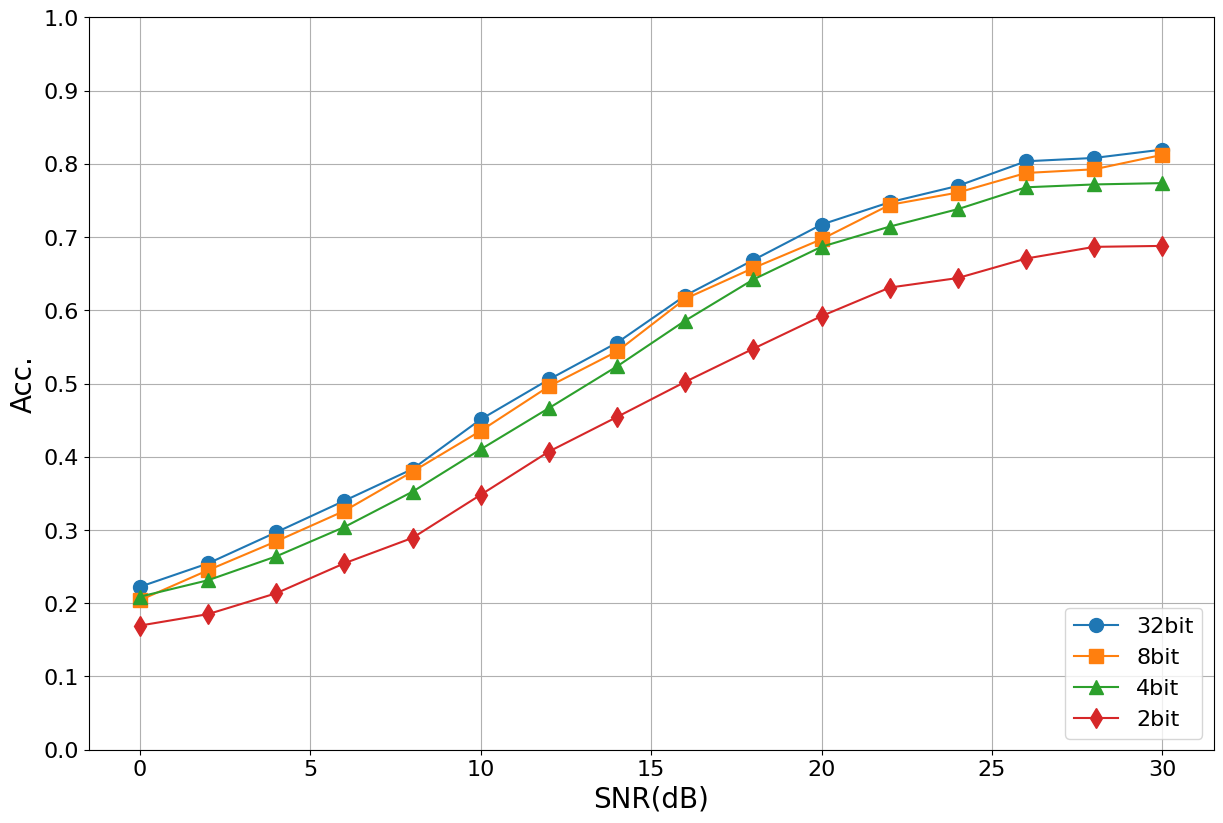

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rician_PPM0]-test[rayleigh_PPM0]


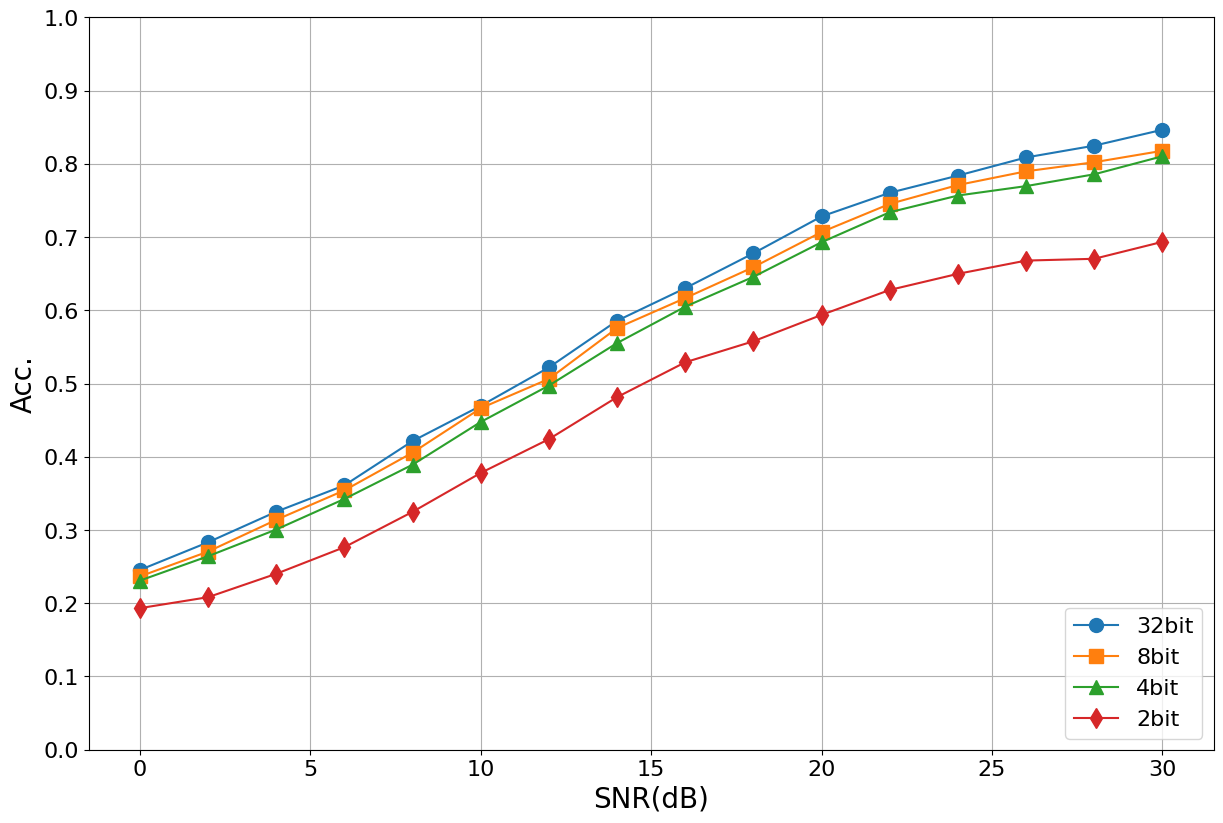

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rician_PPM20]-test[rayleigh_PPM0]


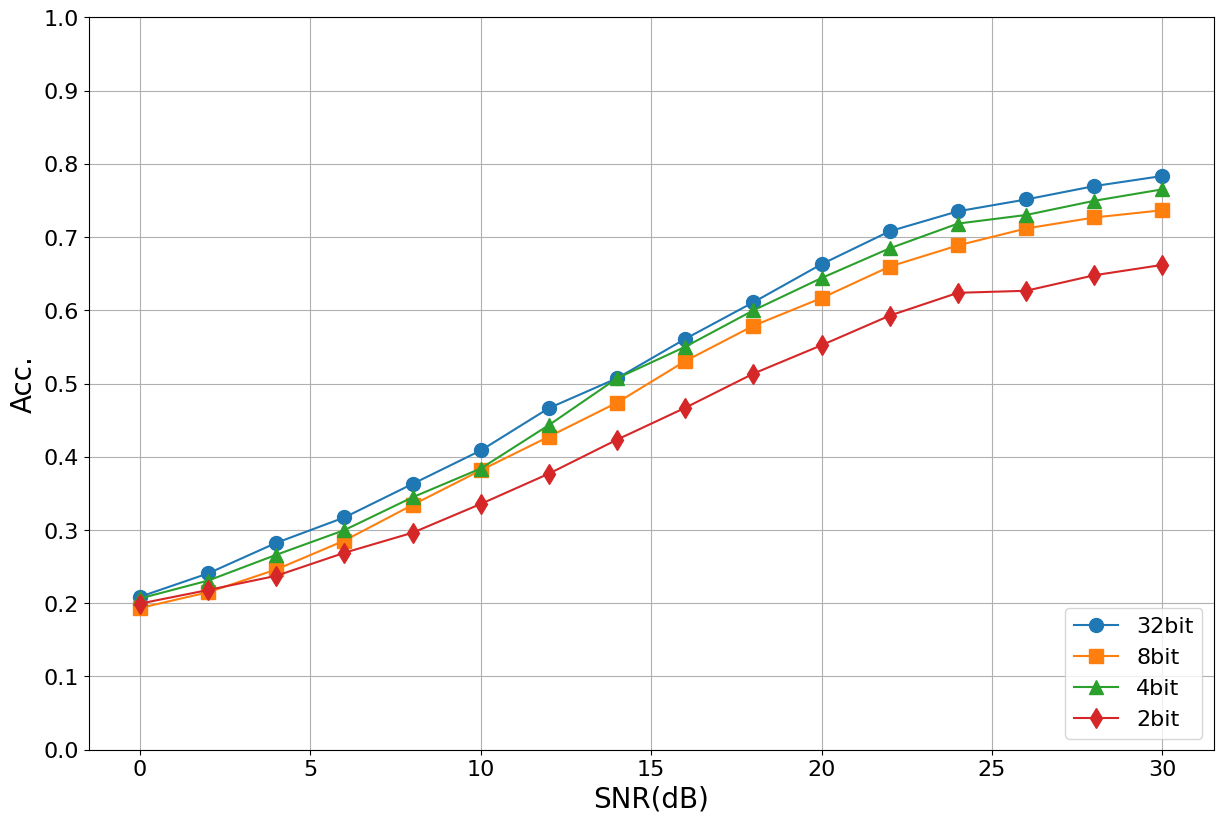

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rayleigh_PPM0]-test[rayleigh_PPM0]


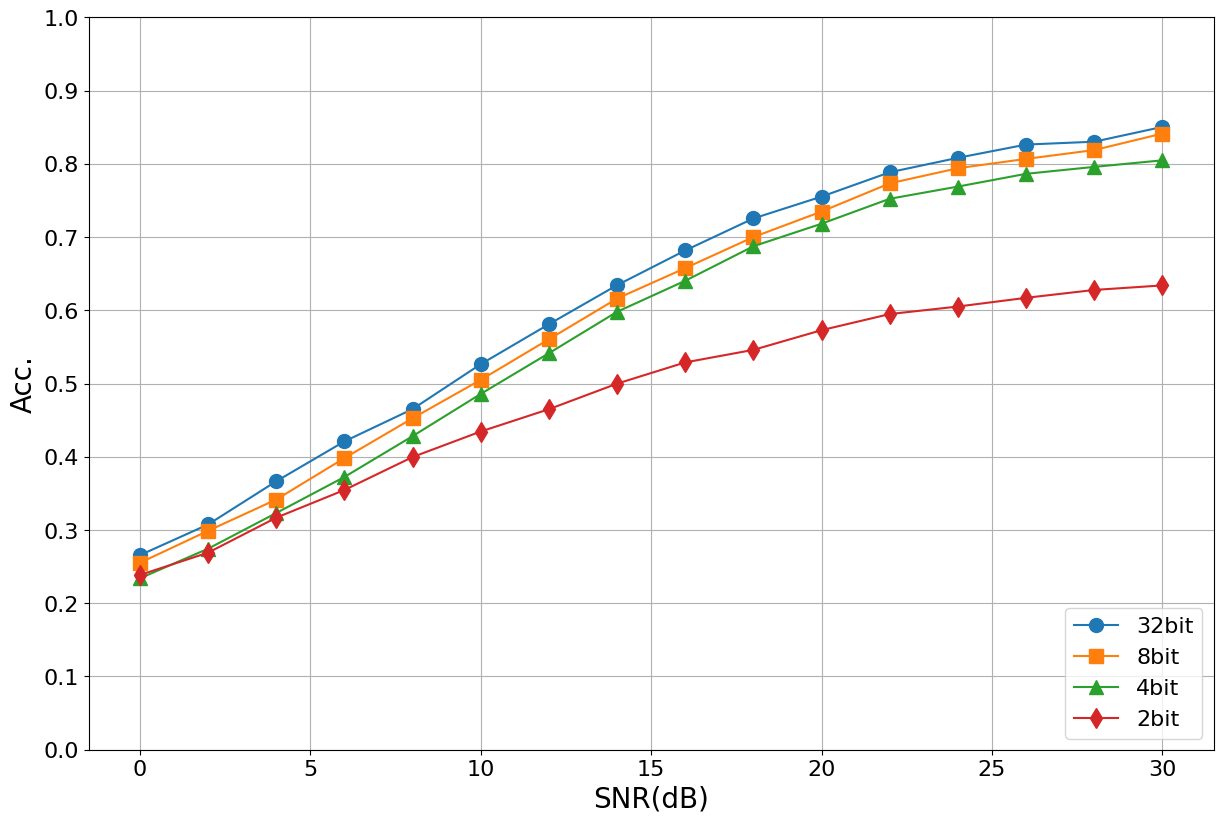

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm0_rayleigh_int8_20250928.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rayleigh_PPM20]-test[rayleigh_PPM0]


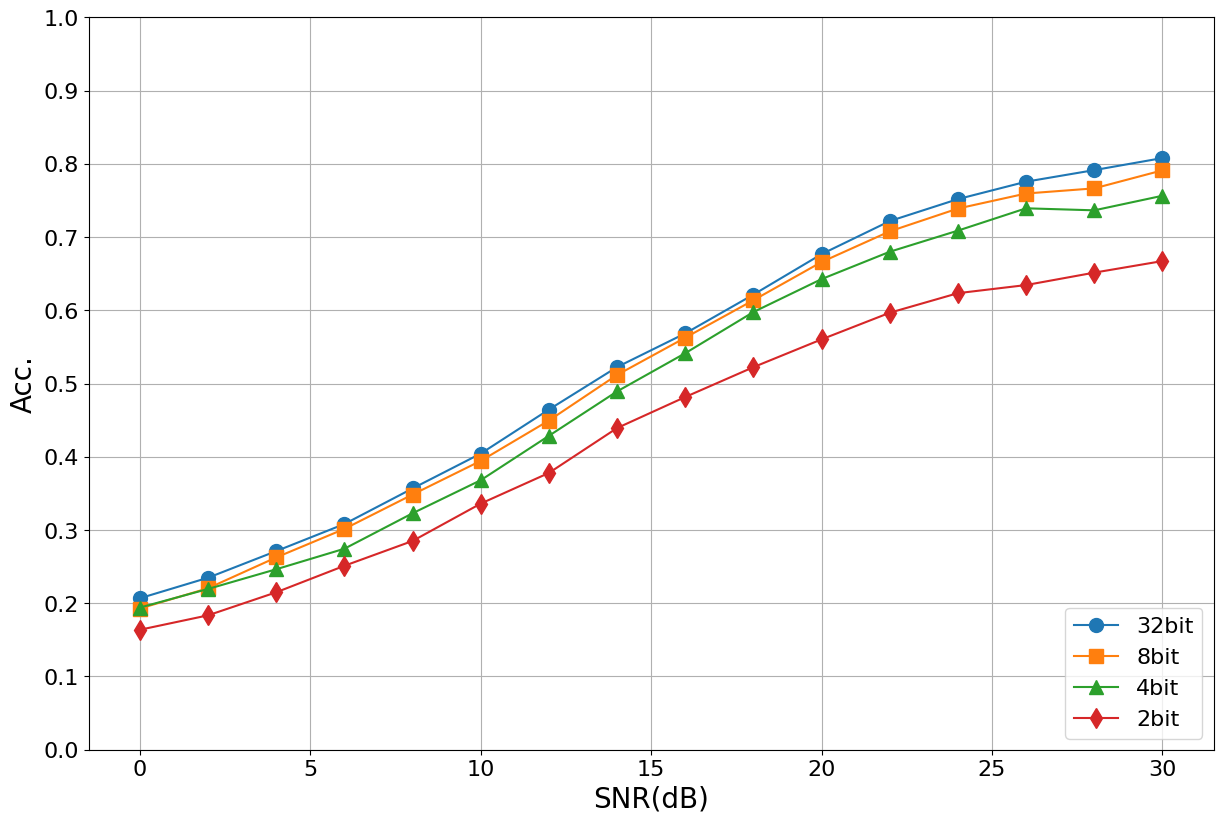

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rician_PPM0]-test[rayleigh_PPM20]


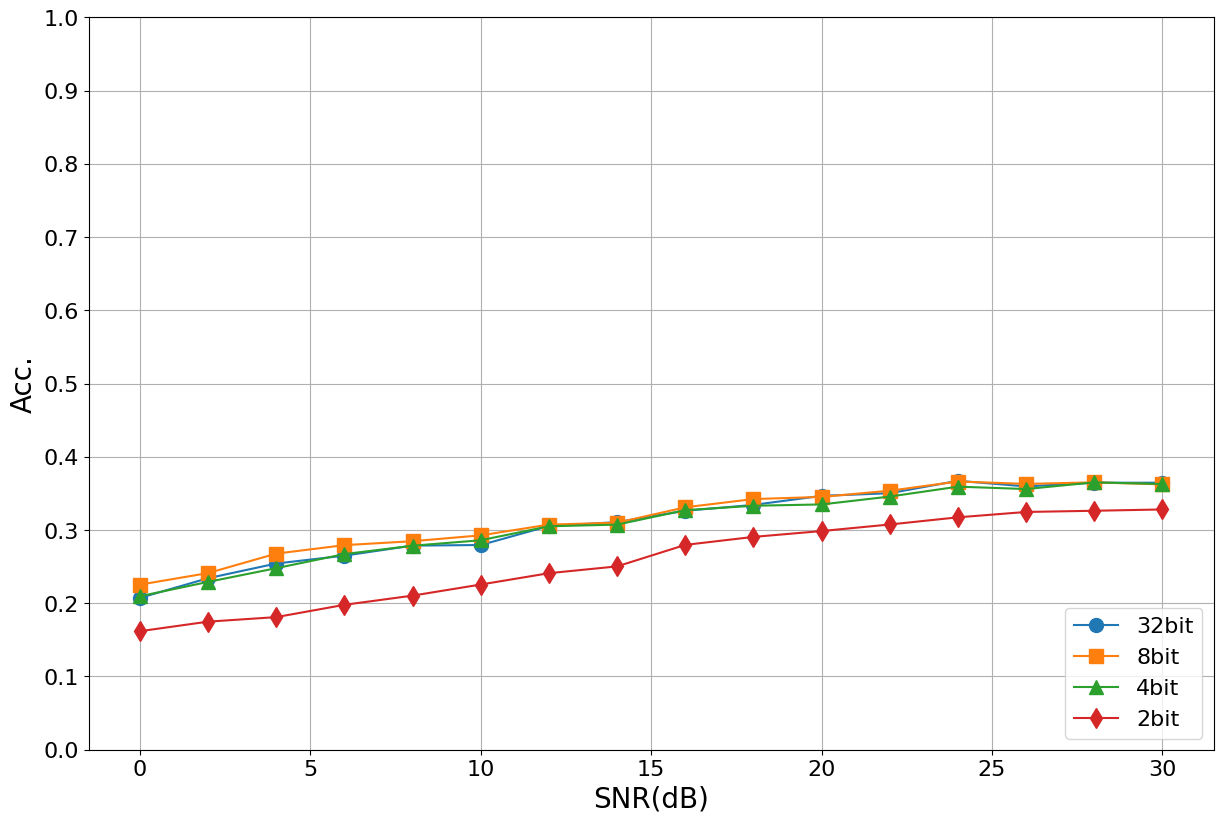

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rician_PPM20]-test[rayleigh_PPM20]


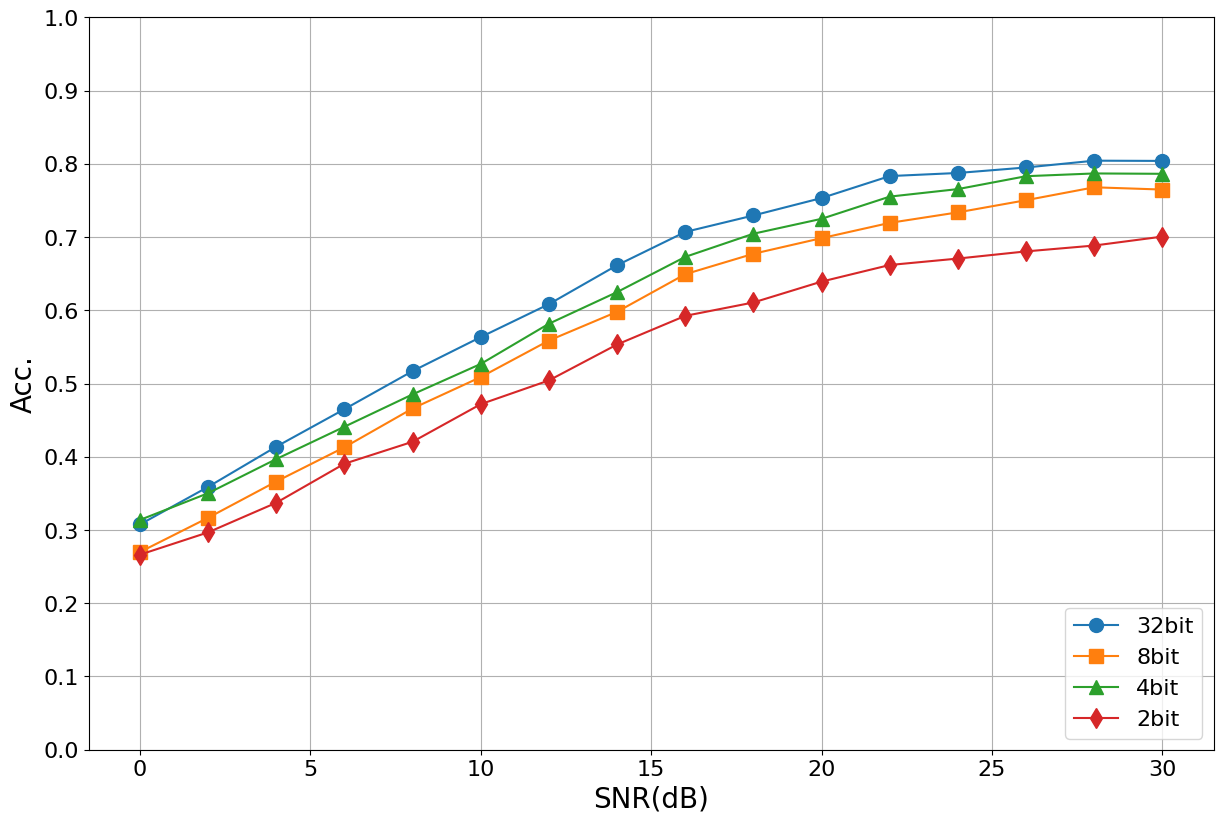

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rayleigh_PPM0]-test[rayleigh_PPM20]


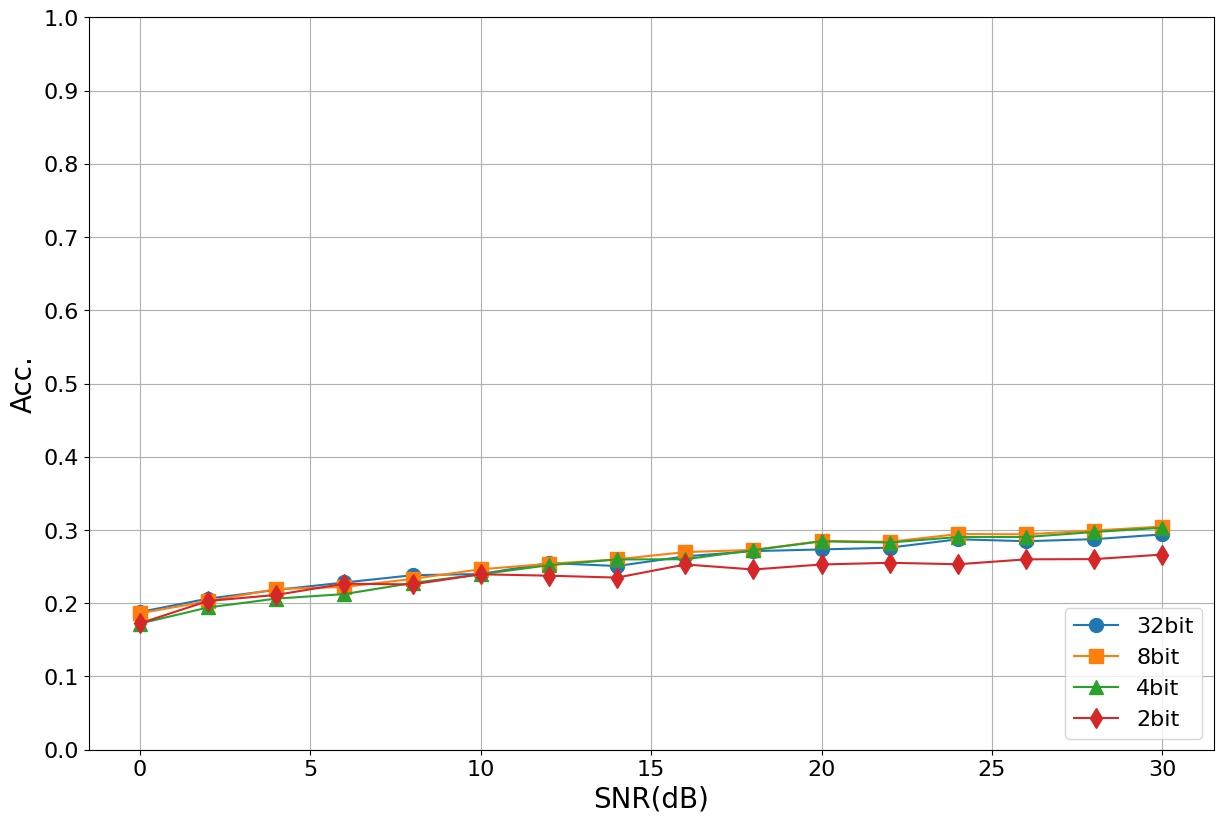

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

loading datasets/MatGenData_ppm20_rayleigh_int8_20260204.h5


Batches:   0%|          | 0/96 [00:00<?, ?it/s]

cross_testing_result/ACCSNR_trained[rayleigh_PPM20]-test[rayleigh_PPM20]


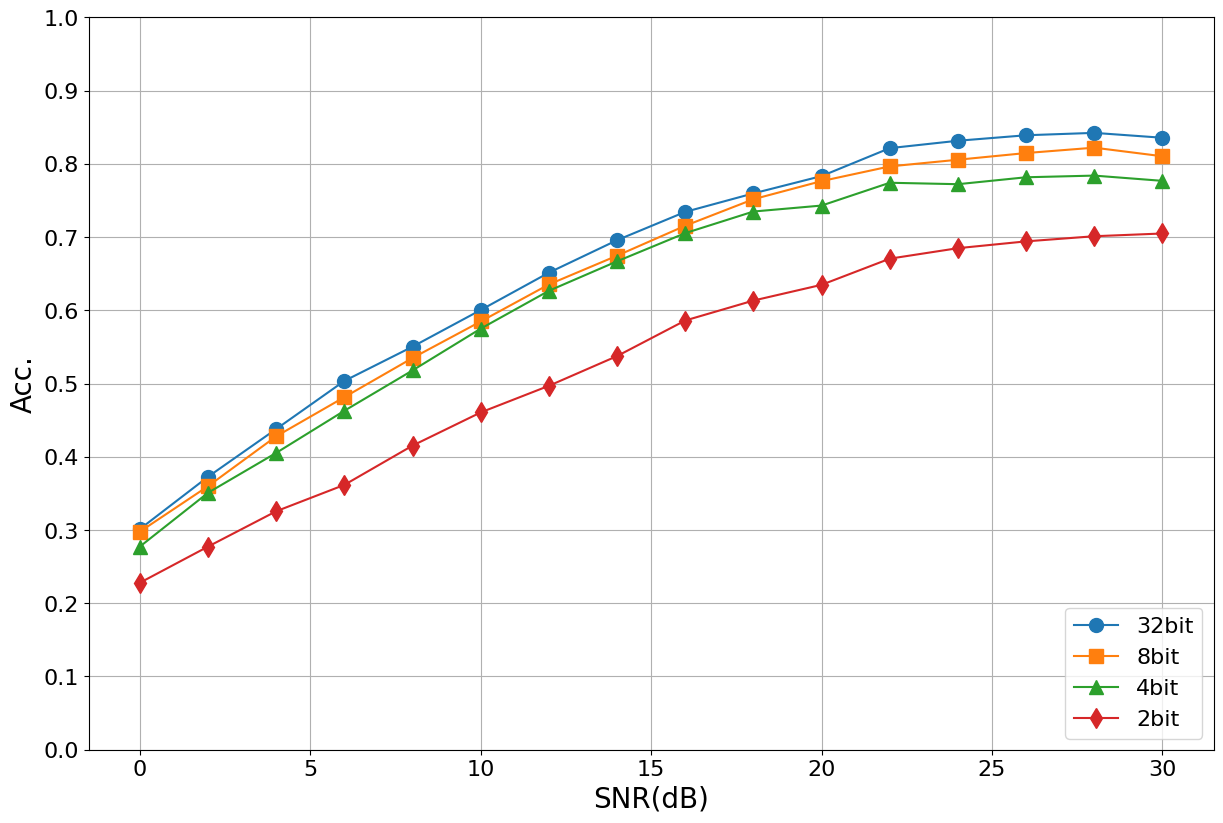

64


In [8]:
mod_classes = ["BPSK", 
                "QPSK", 
                "8PSK",
                "16QAM",
                "32QAM", 
                "64QAM", 
                "128QAM", 
                "256QAM",
                "16APSK", 
                "32APSK", 
                "64APSK", 
                "128APSK",
                "FM", 
                "AM-DSB-SC", 
                "AM-SSB-SC"]

lbl_count:int=len(mod_classes)
snr_list=np.arange(0.0,31.0,2.0)
plot_parent_dir="cross_testing_result"
Path(plot_parent_dir).mkdir(exist_ok=True)

def confusion_matrix_breakdown(train_r:str,train_ppm:int, train_bit:int, test_r:str, test_ppm:str):
    model=get_model(train_r,train_ppm,train_bit)
    dataset_path=get_dataset_path(test_r,test_ppm)
    result=get_model_testing_result(model,dataset_path)

    filter_snr_list=[
        ["0" , [0] ],
        ["10", [10]],
        ["20", [20]],
        ["30", [30]],
        ["all", None]
    ]
    
    for i in range(len(filter_snr_list)):
        conf=get_cm(result, lbl_count, normalized=True, filter_snr=filter_snr_list[i][1])
        plot_confusion_matrix(conf, labels=mod_classes, threshold=0.2, name=f"{plot_parent_dir}/CM_trained[{train_r}_PPM{train_ppm}_{train_bit}bit]-test[{test_r}_PPM{test_ppm}_SNR{filter_snr_list[i][0]}]", use_save=True)

def get_acc_over_snr(train_r:str,train_ppm:int, train_bit:int, test_r:str, test_ppm:str):
    model=get_model(train_r,train_ppm,train_bit)
    dataset_path=get_dataset_path(test_r,test_ppm)
    result=get_model_testing_result(model,dataset_path)

    correct_over_snr, total_over_snr= get_acc_breakdown_over_snr(result, label_count=lbl_count)

    acc_over_snr_per_mod=correct_over_snr/total_over_snr
    avg_acc_over_snr=np.sum(correct_over_snr,axis=1)/np.sum(total_over_snr,axis=1)

    return acc_over_snr_per_mod,avg_acc_over_snr
        
def main():    
    # test_rician_on_rician=get_model_testing_result(get_model("rician",0,8),"datasets/MatGenData_ppm0_rician_int8_20260213.h5")
    # # conf=get_cm(test_rician_on_rician, lbl_count, normalized=True, filter_snr=[10.0])
    # # plot_confusion_matrix(conf, labels=mod_classes, threshold=0.2, title="Confusion Matrix of 8bit Model (train: Rician PPM0 | test: Rician PPM0)")

    # correct_over_snr, total_over_snr= get_acc_breakdown_over_snr(test_rician_on_rician, label_count=lbl_count)

    # snr_x_ticks=np.arange(0.0,31.0,2.0)
    # # acc_brkdown=correct_over_snr/total_over_snr
    # # graph_multiline(acc_brkdown,snr_x_ticks, mod_classes, title="Accuracy Breakdown of 8bit Model (train:Rician PPM0 | test: RicianPPM0)")

    # acc_over_snr=np.sum(correct_over_snr,axis=1)/np.sum(total_over_snr,axis=1)
    # # graph_multiline(acc_over_snr,snr_x_ticks, None,title="Accuracy Breakdown of 8bit Model (train:Rician PPM0 | test: RicianPPM0)")

    # test_rician_on_rician_4bit=get_model_testing_result(get_model("rician",0,4),"datasets/MatGenData_ppm0_rician_int8_20260213.h5")
    # correct_over_snr1, total_over_snr1= get_acc_breakdown_over_snr(test_rician_on_rician_4bit, label_count=lbl_count)
    # acc_over_snr1=np.sum(correct_over_snr1,axis=1)/np.sum(total_over_snr1,axis=1)

    # test_rician_on_rician_2bit=get_model_testing_result(get_model("rician",0,2),"datasets/MatGenData_ppm0_rician_int8_20260213.h5")
    # correct_over_snr2, total_over_snr2= get_acc_breakdown_over_snr(test_rician_on_rician_2bit, label_count=lbl_count)
    # acc_over_snr2=np.sum(correct_over_snr2,axis=1)/np.sum(total_over_snr2,axis=1)
    
    # graph_multiline(np.array([acc_over_snr,acc_over_snr1,acc_over_snr2]).transpose(),x_data=snr_x_ticks, x_label=np.arange(0.0,31.0,5.0), legends=["8bit","4bit","2bit"],title="")
    fading_models=["rician","rayleigh"]
    ppm_list=[0,20]
    bit_list=[32,8,4,2]
    count=0
    #test
    for test_r in fading_models:
        for test_ppm in ppm_list:
            #train
            # acc_snr_per_mod=[]
            for train_r in fading_models:
                for train_ppm in ppm_list:
                    avg_acc_snr=[]
                    legend=[]
                    for train_b in bit_list:
                        count+=1

                        per_mod,avg=get_acc_over_snr(train_r,train_ppm,train_b,test_r,test_ppm)
                        # acc_snr_per_mod.append(per_mod)
                        avg_acc_snr.append(avg)
                        # with open(f"{plot_parent_dir}/[{train_r}_{train_ppm}_{train_b}_GPU]_[{test_r}_{test_ppm}].npy","wb") as f:
                        #     np.save(f,avg)
                        legend.append(f"{train_b}bit")
                        # confusion_matrix_breakdown(train_r,train_ppm,train_b,test_r,test_ppm)
                    graph_multiline(np.array(avg_acc_snr).transpose(),x_data=snr_list, x_label=np.arange(0.0,31.0,5.0), legends=legend, name=f"{plot_parent_dir}/ACCSNR_trained[{train_r}_PPM{train_ppm}]-test[{test_r}_PPM{test_ppm}]",use_save=True)
    print(count)
main()